# Monthly mean correlations using annual sea ice mask

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import glob
import warnings
from pathlib import Path
import s3fs
import matplotlib
import gsw
import cmocean
import time
from scipy.stats import t
import calendar
import time
from scipy.stats import linregress

In [2]:
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [4]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:45305")
client

<Client: 'tcp://127.0.0.1:45305' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [11]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open monthly mean ZARR datasets

In [8]:
# open SALT zarr store - [psu]
SALT_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_MONTHLY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_MONTHLY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_MONTHLY.ZARR/', s3_options)

# open RHOAnoma zarr store - [fraction of sea ice, 0 to 1]
RHOAnoma_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_MONTHLY.ZARR/', s3_options)

In [27]:
# remove 2021 to since we only have January and a few days in Feb that year
salt_month = SALT_zarr.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_month = THETA_zarr.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_month = SI_zarr.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

# add reference density to density anomaly (RHOAnoma)
rhoConst = 1027.5 # reference density
density_month = RHOAnoma_zarr.RHOAnoma.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1) + rhoConst

### Open daily mean ZARR datasets

In [9]:
# open SALT zarr store - [psu]
# SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
# THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

# open RHOAnoma zarr store - [fraction of sea ice, 0 to 1]
# RHOAnoma_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options)

In [12]:
# remove 2021 to since we only have January and a few days in Feb that year
# salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
# theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

# add reference density to density anomaly (RHOAnoma)
# rhoConst = 1027.5 # reference density
# density_day = RHOAnoma_zarr_day.RHOAnoma.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1) + rhoConst

In [13]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

## Mask grid cells that are covered in sea ice year-round

#### One option is to identify grid cells that are covered in sea ice for the entire 7 year time series (above a certain threshold)

In [40]:
start_time = time.time()

# define the threshold for ice presence
# ice_threshold = 15 # percent
ice_threshold = 25 # percent

# identify cells covered in ice year-round
ice_year_round_mask = (ice_day >= ice_threshold).all(dim='time').compute()

# end time
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.6f} seconds")

Execution time: 4.668545 seconds


In [41]:
# mask out cells covered in ice year-round
salt_ice_masked = salt_day.where(~ice_year_round_mask)

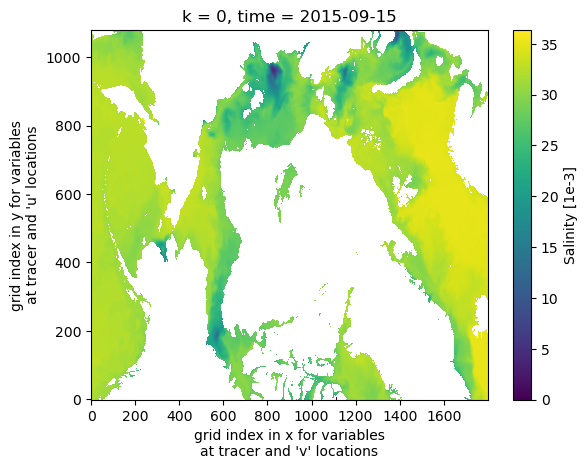

In [42]:
salt_ice_masked.isel(time=20,k=0).plot()

#### Another option is to mask out grid cells that are covered in sea ice using the annual climatology from the 7 years

In [14]:
ice_annual_clim = ice_day.mean(dim='time').compute()

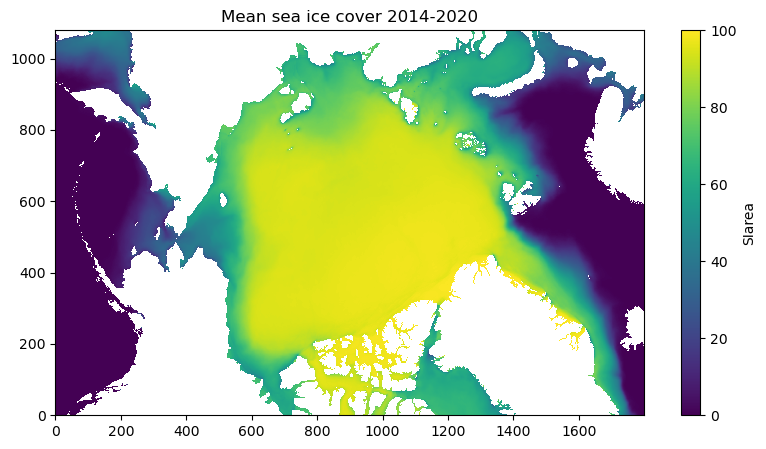

In [15]:
ice_annual_clim.plot(vmin=0,vmax=100,figsize=[9.5,5]);
plt.ylabel("")
plt.xlabel("")
plt.title("Mean sea ice cover 2014-2020");

In [16]:
ice_cover_mask = (ice_annual_clim >= 85).compute()

### Mask ice covered grid cells from datasets

In [32]:
salt_ice_masked = salt_month.where(~ice_cover_mask)
theta_ice_masked = theta_month.where(~ice_cover_mask)

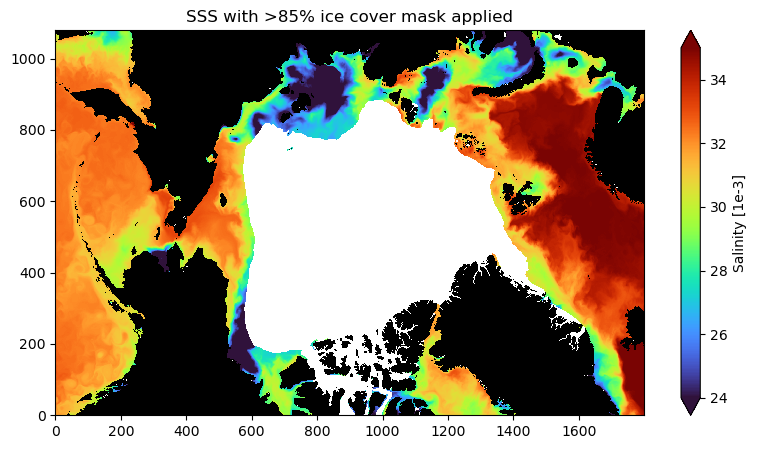

In [33]:
salt_ice_masked.isel(time=20,k=0).plot(vmin=24,vmax=35,cmap='turbo',figsize=[9.5,5]);
HH_grid_land.plot(vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
plt.ylabel("")
plt.xlabel("")
plt.title("SSS with >85% ice cover mask applied");

## Correlation between SSS and $\Delta \sigma_{\theta} =  \sigma_{\theta, 20 \, \text{m}} - \sigma_{\theta, \text{surface}}$

In [41]:
def sig_corr(corr_da, n):
    """
    Determine which correlations are statistically significant
    Mask insignificant values in provided array and return only signficant values

    n : sample size
    corr_da : correlation coefficients
    """
    
    # compute the t-statistic
    t_stat = corr_da * np.sqrt((n - 2) / (1 - corr_da**2))

    # compute p-values using the survival function (1 - CDF)
    p_values = 2 * t.sf(np.abs(t_stat), df=n - 2)

    # determine significance at alpha=0.05
    alpha = 0.05
    # mask non-significant correlations
    corr_significant = corr_da.where(p_values < alpha)
    
    return corr_significant

In [34]:
print(density_month.isel(k=0).Z.values)
print(density_month.isel(k=10).Z.values)

-0.5
-21.125


In [35]:
# calculate delta sigma
delta_sigma_20m = density_month.isel(k=10) - density_month.isel(k=0)

In [37]:
# apply ice mask to delta rho
delta_sigma_20m_masked = delta_sigma_20m.where(~ice_cover_mask)

In [40]:
corr_20minus0 = xr.corr(salt_ice_masked.isel(k=0), delta_sigma_20m_masked, dim='time').compute()

In [43]:
significant_corr_20minus0 = sig_corr(corr_20minus0, len(salt_ice_masked['time']))

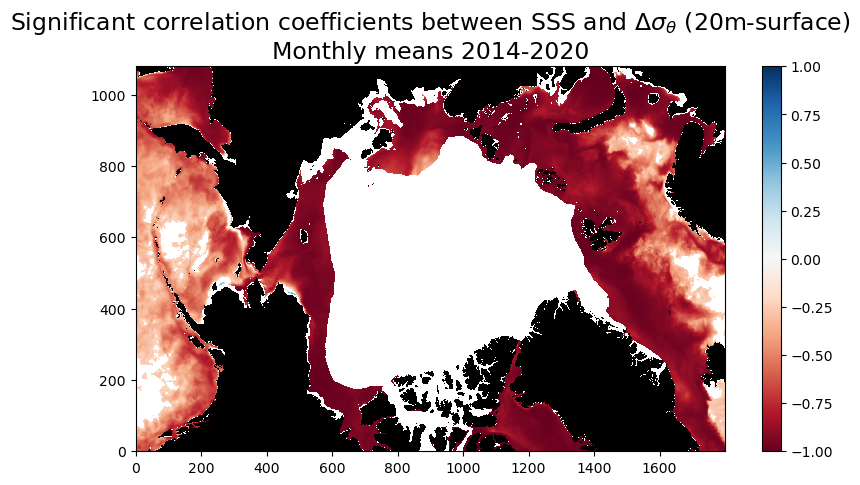

In [44]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
significant_corr_20minus0.plot(ax=ax,cmap='RdBu',vmin=-1,vmax=1);
# ax.set_facecolor('gray')
HH_grid_land.plot(vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
ax.set_xlabel("")
ax.set_ylabel("")
# ax.set_title('Correlation coefficients between\nSSS and ' + r'$\Delta \sigma_{\theta}$ (20m-surface)' + '\nMonthly means 2014-2020', size=17);
ax.set_title(r'Significant correlation coefficients between SSS and $\Delta \sigma_{\theta}$ (20m-surface)' + '\nMonthly means 2014-2020', size=17);

## Correlation between SSS and $\Delta \sigma_{\theta} =  \sigma_{\theta, 100 \, \text{m}} - \sigma_{\theta, \text{surface}}$

In [45]:
print(density_month.isel(k=0).Z.values)
print(density_month.isel(k=21).Z.values)

-0.5
-99.37


In [46]:
# calculate delta sigma
delta_sigma_100m = density_month.isel(k=21) - density_month.isel(k=0)

In [47]:
corr_100minus0 = xr.corr(salt_ice_masked.isel(k=0), delta_sigma_100m, dim='time').compute()

In [48]:
significant_corr_100minus0 = sig_corr(corr_100minus0, len(salt_ice_masked['time']))

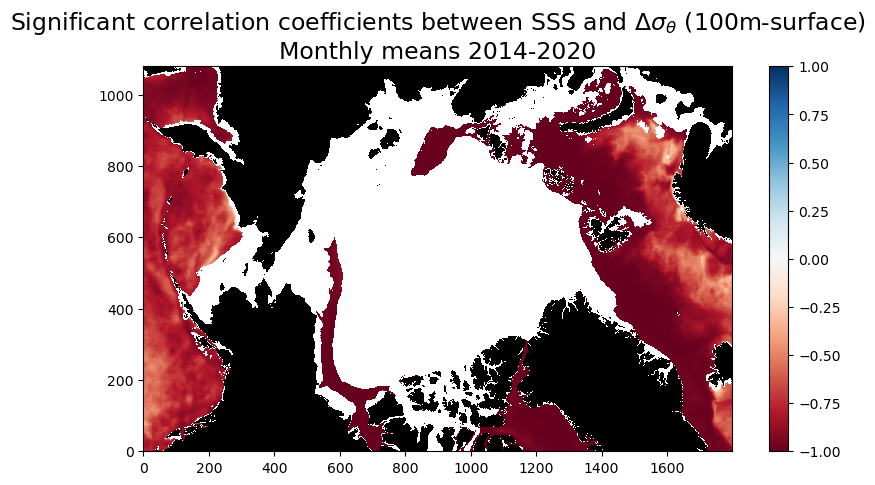

In [49]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
significant_corr_100minus0.plot(ax=ax,cmap='RdBu',vmin=-1,vmax=1);
# ax.set_facecolor('gray')
HH_grid_land.plot(vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
ax.set_xlabel("")
ax.set_ylabel("")
# ax.set_title('Correlation coefficients between\nSSS and ' + r'$\Delta \sigma_{\theta}$ (100m-surface)' + '\nMonthly means 2014-2020', size=17);
ax.set_title(r'Significant correlation coefficients between SSS and $\Delta \sigma_{\theta}$ (100m-surface)' + '\nMonthly means 2014-2020', size=17);

## Scatter plots

In [60]:
# initialize dictionaries to store results for each month
sigma_dict = {}
salt_dict = {}
theta_dict = {}

# iterate over all months
for month in range(1, 13):
    # select data for the current month
    sigma_flat = delta_sigma_20m_masked.sel(time=delta_sigma_20m['time.month'] == month).values.flatten()
    salt_flat = salt_ice_masked.isel(k=0).sel(time=salt_ice_masked['time.month'] == month).values.flatten()
    theta_flat = theta_ice_masked.isel(k=0).sel(time=theta_ice_masked['time.month'] == month).values.flatten()
    
    # create a mask based on NaNs in delta_sigma_20m
    # first remove nans
    nan_mask = ~np.isnan(sigma_flat)
    
    # Store masked and flattened data
    sigma_dict[month] = sigma_flat[nan_mask]
    salt_dict[month] = salt_flat[nan_mask]
    theta_dict[month] = theta_flat[nan_mask]

# access data for any specific month, e.g., June (6):
sigma_Jun = sigma_dict[6]
salt_Jun = salt_dict[6]
theta_Jun = theta_dict[6]

In [61]:
print(len(sigma_Jun))
print(len(salt_Jun))
print(len(theta_Jun))

5270496
5270496
5270496


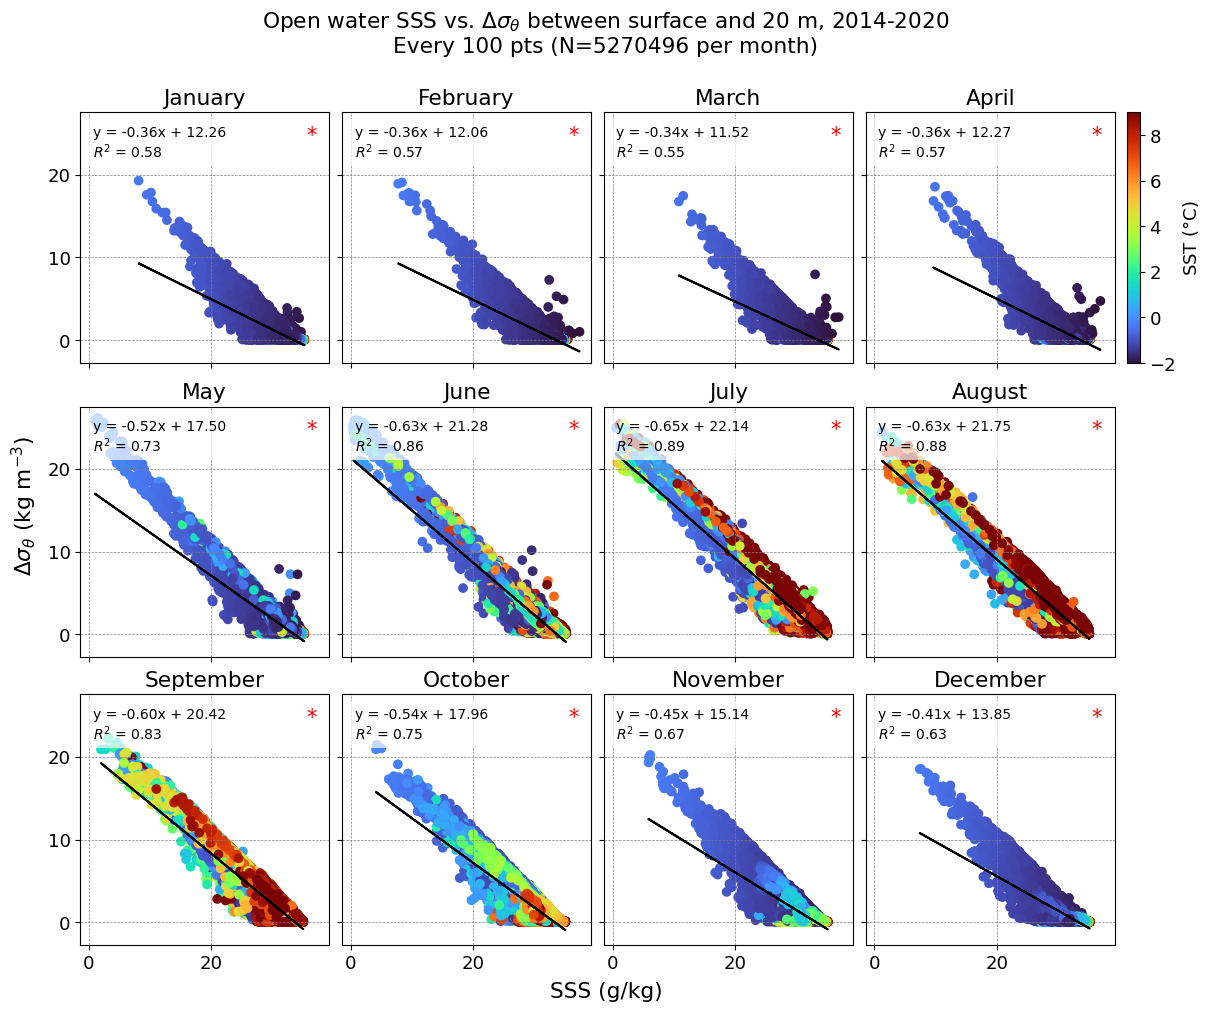

Time taken to plot: 0.2180 minutes


In [64]:


# Measure time to generate plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# Create subplots
fig, axes = plt.subplots(3, 4, figsize=[12, 10], sharey=True, sharex=True, layout='constrained')

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Loop through each month and corresponding subplot
for month in range(1, 13):
    ax = axes[month - 1]  # Access subplot for the current month
    x = salt_dict[month][::100]  # Sample every 100th point
    y = sigma_dict[month][::100]
    
    # Scatter plot
    scatter = ax.scatter(
        x, y,
        c=theta_dict[month][::100],
        cmap='turbo', vmin=-2, vmax=9
    )
    ax.grid(linestyle='dashed', color='gray', linewidth=0.5)
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    y_fit = slope * x + intercept
    
    # Plot the best fit line
    ax.plot(x, y_fit, color='black', linewidth=1.5)
    
    # Add the equation and R^2 to the plot
    r2 = r_value**2
    ax.text(0.05, 0.95, f"y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r2:.2f}",
            transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    
    # Add significance star if p-value < 0.05
    if p_value < 0.05:
        ax.text(0.95, 0.95, "*", transform=ax.transAxes, fontsize=15, color='red', 
                verticalalignment='top', horizontalalignment='right')
    
    # Title for each subplot
    ax.set_title(calendar.month_name[month])

# Add shared labels
fig.supxlabel("SSS (g/kg)")
fig.supylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# Add a colorbar for the 4th subplot only
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='turbo', norm=plt.Normalize(vmin=-2, vmax=9)),
    ax=axes[3],  # The 4th subplot
    location='right'
)
cbar.ax.set_ylabel('SST ($\degree$C)')

# Add a title
plt.suptitle(r'Open water SSS vs. $\Delta \sigma_{\theta}$ between surface and 20 m, 2014-2020' + 
             f'\nEvery 100 pts (N={len(sigma_dict[2])} per month)\n')

plt.show()

end_time = time.time()

# Calculate elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")

#### Plot counts per cell to see density of points

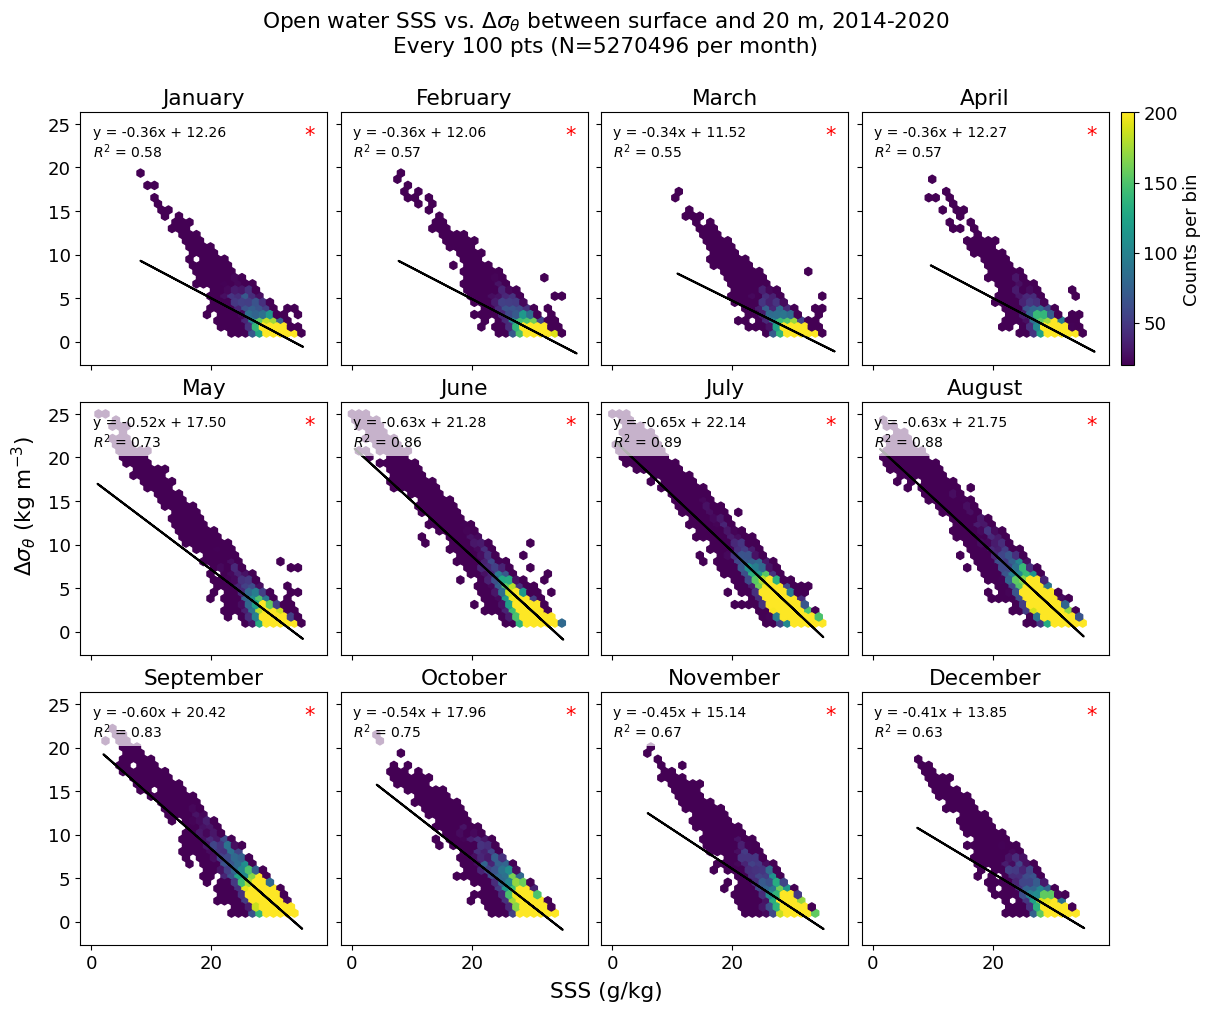

Time taken to plot: 0.0365 minutes


In [65]:
# Measure time to generate plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# Create subplots
fig, axes = plt.subplots(3, 4, figsize=[12, 10], sharey=True, sharex=True, layout='constrained')

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Define the extent for the hexbin plots
extent = [0, 35, 1, 25]

# Loop through each month and corresponding subplot
for month in range(1, 13):
    ax = axes[month - 1]  # Access subplot for the current month
    x = salt_dict[month][::100]  # Sample every 100th point
    y = sigma_dict[month][::100]
    
    # Hexbin plot
    hexbin = ax.hexbin(x, y, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=20, vmax=200)
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    y_fit = slope * x + intercept
    
    # Plot the best fit line
    ax.plot(x, y_fit, color='black', linewidth=1.5)
    
    # Add the equation and R^2 to the plot
    r2 = r_value**2
    ax.text(0.05, 0.95, f"y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r2:.2f}",
            transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    
    # Add significance star if p-value < 0.05
    if p_value < 0.05:
        ax.text(0.95, 0.95, "*", transform=ax.transAxes, fontsize=15, color='red', 
                verticalalignment='top', horizontalalignment='right')
    
    # Title for each subplot
    ax.set_title(calendar.month_name[month])

# Add shared labels
fig.supxlabel("SSS (g/kg)")
fig.supylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# Add a colorbar for the hexbin plot
cbar = fig.colorbar(hexbin, ax=axes[3], location='right')
cbar.ax.set_ylabel('Counts per bin')

# Add a title
plt.suptitle(r'Open water SSS vs. $\Delta \sigma_{\theta}$ between surface and 20 m, 2014-2020' + 
             f'\nEvery 100 pts (N={len(sigma_dict[2])} per month)\n')

plt.show()

end_time = time.time()

# Calculate elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")